Number of pedestrians detected: 5


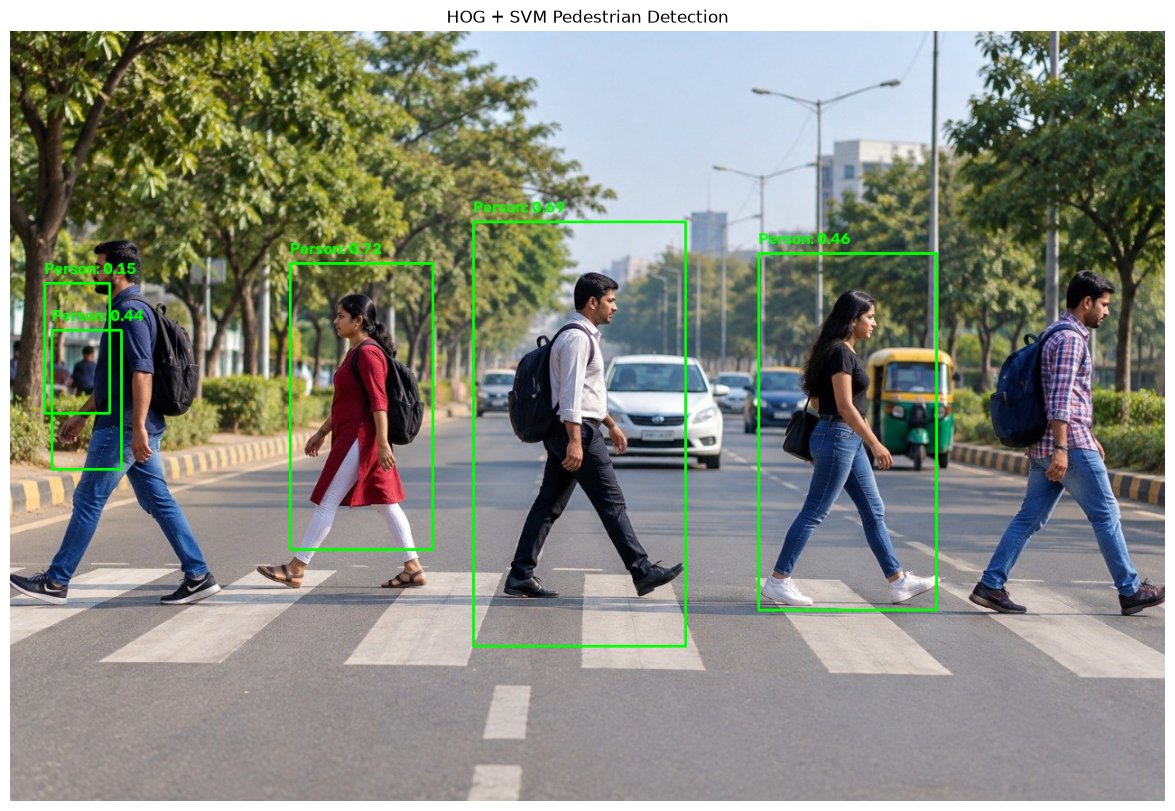

In [5]:
import cv2

# Read input image
image = cv2.imread("/Users/ananyaremani/road1.jpg")

if image is None:
    print("Image not found")
else:
    # Create HOG descriptor
    hog = cv2.HOGDescriptor()

    # Load OpenCV pre-trained pedestrian detector
    hog.setSVMDetector(
        cv2.HOGDescriptor.getDefaultPeopleDetector()
    )

    # Detect pedestrians
    (rects, weights) = hog.detectMultiScale(
        image,
        winStride=(4, 4),
        padding=(8, 8),
        scale=1.03
    )

    # Draw bounding boxes
    for (x, y, w, h), weight in zip(rects, weights):

        cv2.rectangle(
            image,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            f"Person: {float(weight):.2f}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    print("Number of pedestrians detected:", len(rects))

    # Display using Matplotlib
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("HOG + SVM Pedestrian Detection")
    plt.show()